In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-05-23 07:54:44.035695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779522884.244915      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779522884.308084      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779522884.815260      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779522884.815299      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779522884.815301      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


In [2]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])

import kagglehub, os, shutil


raw_path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
print(f"Downloaded to: {raw_path}")

pet_dir = None
for root, dirs, files in os.walk(raw_path):
    if "Cat" in dirs and "Dog" in dirs:
        pet_dir = root
        break
print(f"PetImages found at: {pet_dir}")


import random
from PIL import Image

def safe_images(src_folder):
    """Return list of non-corrupted images"""
    valid = []
    for f in os.listdir(src_folder):
        fpath = os.path.join(src_folder, f)
        try:
            img = Image.open(fpath)
            img.verify()
            valid.append(fpath)
        except:
            pass
    return valid

for split in ["train", "test"]:
    for cls in ["dogs", "cats"]:
        os.makedirs(f"data/{split}/{cls}", exist_ok=True)

for cls, folder in [("dogs", "Dog"), ("cats", "Cat")]:
    imgs = safe_images(os.path.join(pet_dir, folder))
    random.seed(42)
    random.shuffle(imgs)
    train_imgs = imgs[:8000]
    test_imgs  = imgs[8000:10000]
    for src in train_imgs:
        shutil.copy(src, f"data/train/{cls}/")
    for src in test_imgs:
        shutil.copy(src, f"data/test/{cls}/")
    print(f"{cls}: {len(train_imgs)} train | {len(test_imgs)} test")

# config
TRAIN_DIR  = "data/train"
TEST_DIR   = "data/test"
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

train_dogs = len(os.listdir(os.path.join(TRAIN_DIR, "dogs")))
train_cats = len(os.listdir(os.path.join(TRAIN_DIR, "cats")))
test_dogs  = len(os.listdir(os.path.join(TEST_DIR,  "dogs")))
test_cats  = len(os.listdir(os.path.join(TEST_DIR,  "cats")))
print(f"Training — Dogs: {train_dogs} | Cats: {train_cats}")
print(f"Test     — Dogs: {test_dogs}  | Cats: {test_cats}")

Downloaded to: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
PetImages found at: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages
dogs: 8000 train | 2000 test
cats: 8000 train | 2000 test
Training — Dogs: 8000 | Cats: 8000
Test     — Dogs: 2000  | Cats: 2000


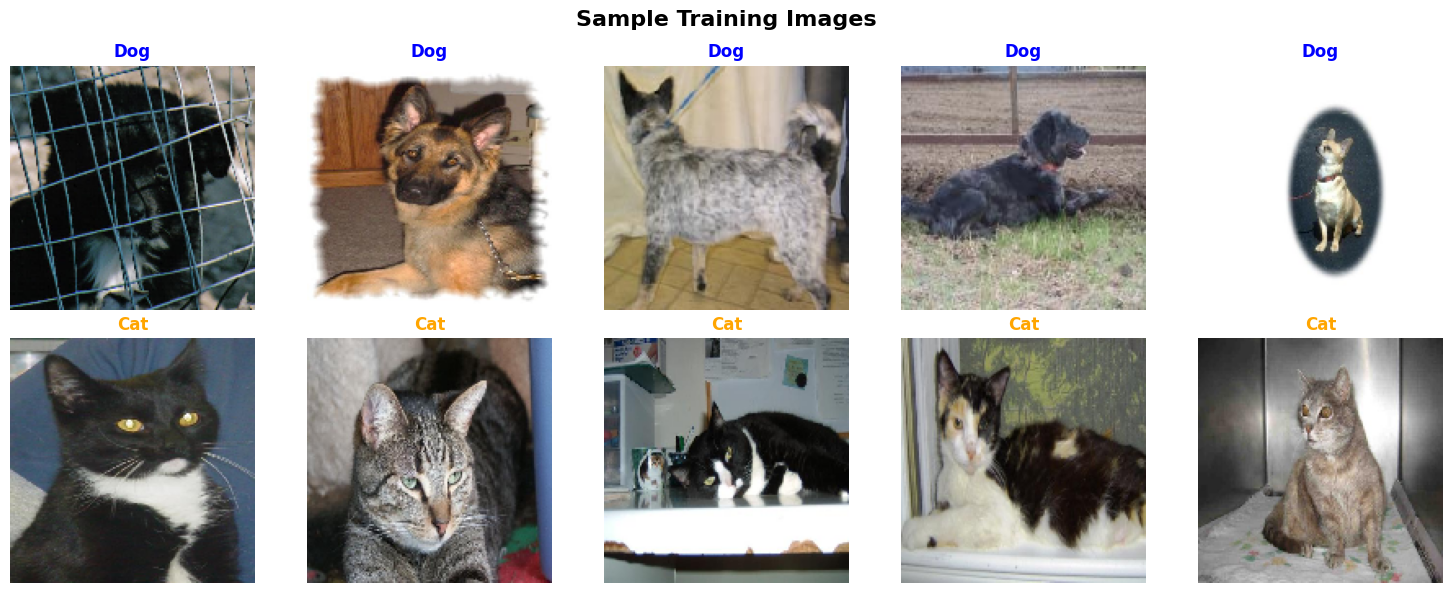

In [4]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes[0]):
    img_path = os.path.join(TRAIN_DIR, 'dogs', os.listdir(os.path.join(TRAIN_DIR, 'dogs'))[i])
    img = load_img(img_path, target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title('Dog', color='blue', fontweight='bold')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    img_path = os.path.join(TRAIN_DIR, 'cats', os.listdir(os.path.join(TRAIN_DIR, 'cats'))[i])
    img = load_img(img_path, target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title('Cat', color='orange', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

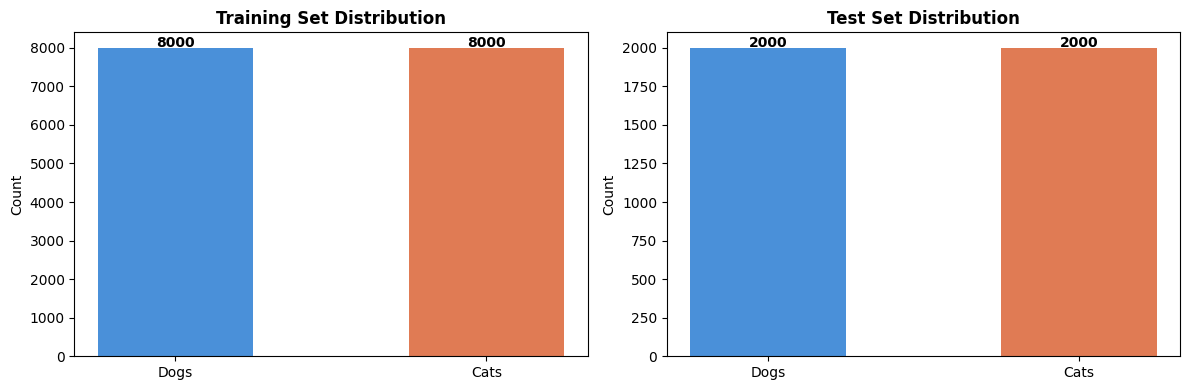

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Dogs', 'Cats'], [train_dogs, train_cats], color=['#4A90D9', '#E07B54'], width=0.5)
axes[0].set_title('Training Set Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([train_dogs, train_cats]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')


axes[1].bar(['Dogs', 'Cats'], [test_dogs, test_cats], color=['#4A90D9', '#E07B54'], width=0.5)
axes[1].set_title('Test Set Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([test_dogs, test_cats]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'Class indices: {train_generator.class_indices}')

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


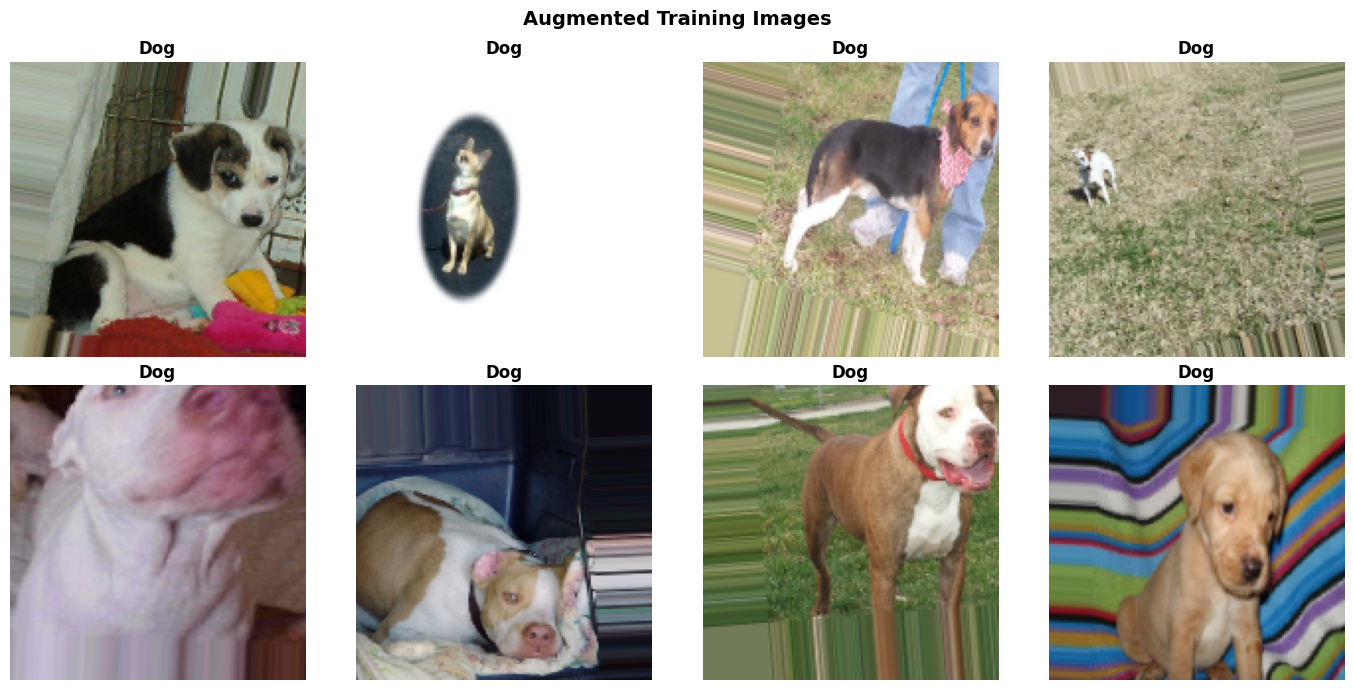

In [7]:
sample_batch = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[0][i])
    label = 'Dog' if sample_batch[1][i] == 1 else 'Cat'
    ax.set_title(label, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=100, bbox_inches='tight')
plt.show()

## 🧠 5. Build Custom CNN Model

In [8]:
def build_cnn_model(input_shape=(150, 150, 3)):
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Classifier
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary: 0=Cat, 1=Dog
    ])
    return model

model = build_cnn_model()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1779523192.009888      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779523192.016129      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,524,641 (82.11 MB)

 Trainable params: 21,523,169 (82.10 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [9]:

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print('\nTraining complete!')
print(f'Best val accuracy: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/20


I0000 00:00:1779523197.923185     155 service.cc:152] XLA service 0x7d8638018a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779523197.923246     155 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779523197.923252     155 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779523198.822385     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-23 08:00:02.382169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 08:00:02.535739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 08:00:03.156719: E external/local_xl

  2/500 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.4375 - loss: 1.1417   

I0000 00:00:1779523212.201670     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5692 - loss: 0.7762
Epoch 1: val_accuracy improved from -inf to 0.60650, saving model to best_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 126s 217ms/step - accuracy: 0.5693 - loss: 0.7760 - val_accuracy: 0.6065 - val_loss: 0.6942
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6676 - loss: 0.6135
Epoch 2: val_accuracy improved from 0.60650 to 0.71125, saving model to best_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 103s 206ms/step - accuracy: 0.6676 - loss: 0.6134 - val_accuracy: 0.7113 - val_loss: 0.5640
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7215 - loss: 0.5549
Epoch 3: val_accuracy improved from 0.71125 to 0.73175, saving model to best_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 202ms/step - accuracy: 0.7216 - loss: 0.5549 - val_accuracy: 0.7318 - val_loss: 0.5566
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7413 - loss: 0.5222
Epoch 4: val_accuracy did not im

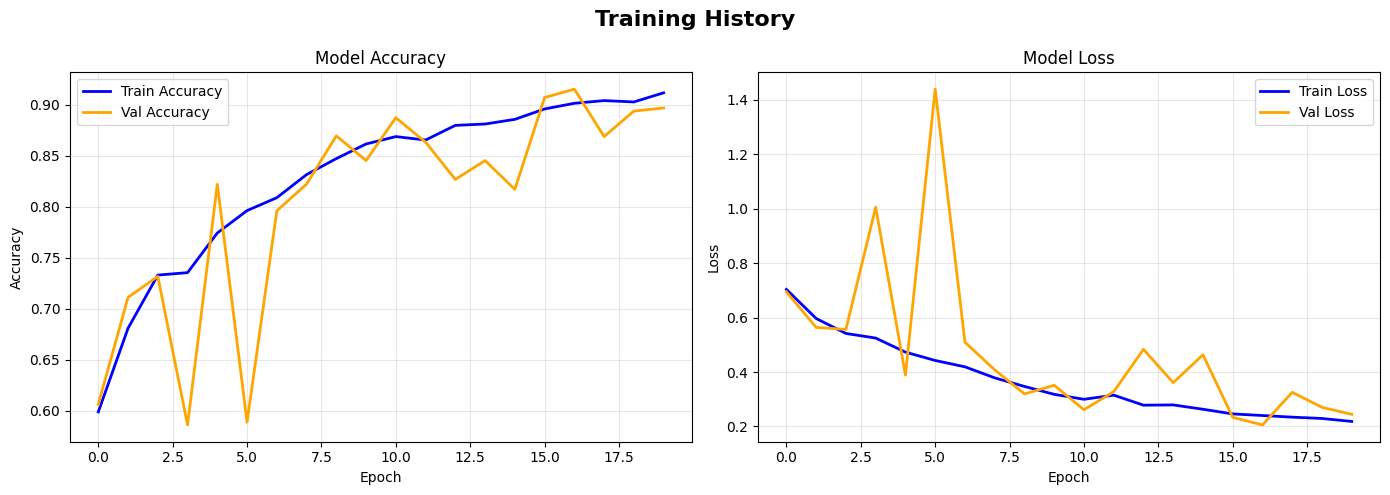

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue',   linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue',   linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:

best_model = tf.keras.models.load_model('best_model.keras')

test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

Test Loss     : 0.2055
Test Accuracy : 0.9153 (91.53%)


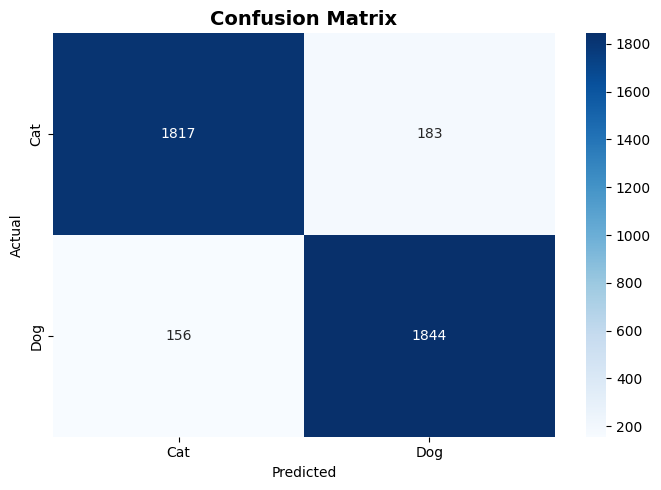


Classification Report:
              precision    recall  f1-score   support

         Cat       0.92      0.91      0.91      2000
         Dog       0.91      0.92      0.92      2000

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000



In [12]:

test_generator.reset()
y_pred_prob = best_model.predict(test_generator, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

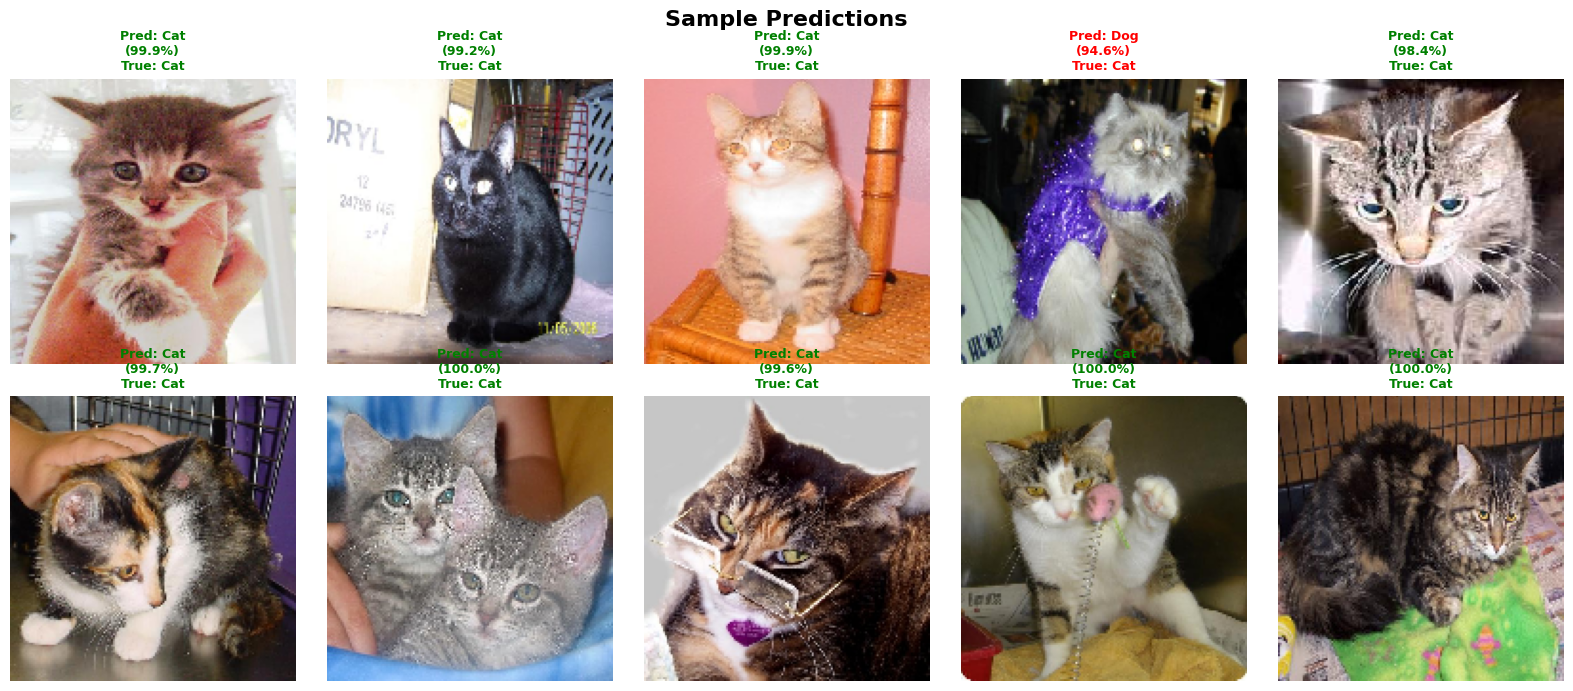

In [13]:

test_generator.reset()
sample_images, sample_labels = next(test_generator)
sample_preds = best_model.predict(sample_images, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Predictions', fontsize=16, fontweight='bold')
class_names = ['Cat', 'Dog']

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    pred_class = class_names[int(sample_preds[i] > 0.5)]
    true_class = class_names[int(sample_labels[i])]
    confidence = sample_preds[i][0] if sample_preds[i] > 0.5 else 1 - sample_preds[i][0]
    color = 'green' if pred_class == true_class else 'red'
    ax.set_title(f'Pred: {pred_class}\n({confidence*100:.1f}%)\nTrue: {true_class}',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
best_model.save('dog_vs_cat_model.keras')
print('Model saved as dog_vs_cat_model.keras')
print('Run app.py with: streamlit run app.py')

Model saved as dog_vs_cat_model.keras
Run app.py with: streamlit run app.py
